Importing Libraries

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import dct, idct
import matplotlib.pyplot as plt
from PIL import Image

Load Noisy Image Data

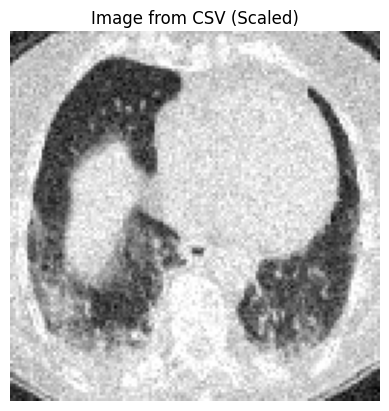

In [19]:
image_matrix = np.loadtxt('/content/noisy_img_mtrx.csv', delimiter=' ')

# Scale to 0–255 and convert to uint8
image_matrix = (image_matrix * 255).clip(0, 255).astype(np.uint8)

plt.imshow(image_matrix, cmap='gray')
plt.title("Image from CSV (Scaled)")
plt.axis('off')
plt.show()


Load Autoencoded Image Data

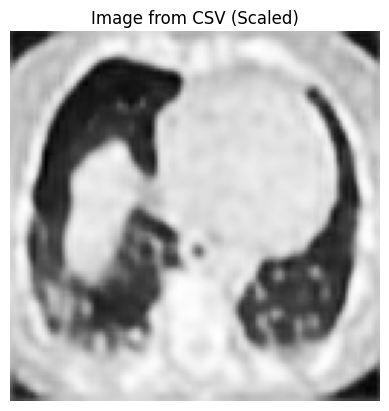

In [20]:
image_matrix = np.loadtxt('/content/autoencoded_img_mtrx.csv', delimiter=' ')

# Scale to 0–255 and convert to uint8
image_matrix = (image_matrix * 255).clip(0, 255).astype(np.uint8)

plt.imshow(image_matrix, cmap='gray')
plt.title("Image from CSV (Scaled)")
plt.axis('off')
plt.show()


In [37]:
def calculate_entropy(csv_path):
    pixel_array = np.loadtxt(csv_path, delimiter=' ')
    pixels = pixel_array.flatten()
    pixels = (pixels * 255).clip(0, 255).astype(np.uint8)
    # Calculate histogram with 256 bins (0–255)
    histogram, _ = np.histogram(pixels, bins=256, range=(0, 256), density=True)
    # Remove zero entries to avoid log(0)
    histogram = histogram[histogram > 0]
    entropy = -np.sum(histogram * np.log2(histogram))
    return entropy

JPEG Compression and Analysis functions

In [21]:
#Setup

# Step 2: Define DCT and Quantization
def dct2(block):
    return dct(dct(block.T, norm='ortho').T, norm='ortho')

def idct2(block):
    return idct(idct(block.T, norm='ortho').T, norm='ortho')

Q = np.array([
    [16,11,10,16,24,40,51,61],
    [12,12,14,19,26,58,60,55],
    [14,13,16,24,40,57,69,56],
    [14,17,22,29,51,87,80,62],
    [18,22,37,56,68,109,103,77],
    [24,35,55,64,81,104,113,92],
    [49,64,78,87,103,121,120,101],
    [72,92,95,98,112,100,103,99]
])

# Step 3: JPEG Compression function
def jpeg_compress_grayscale(img, quality=50):
    h, w = img.shape
    compressed = np.zeros((h, w), dtype=np.float32)

    # Adjust quantization based on quality
    scale = 5000 / quality if quality < 50 else 200 - 2 * quality
    Q_scaled = np.floor((Q * scale + 50) / 100)
    Q_scaled[Q_scaled == 0] = 1

    non_zero_count = 0  # For compression ratio calculation

    for i in range(0, h, 8):
        for j in range(0, w, 8):
            block = img[i:i+8, j:j+8]
            if block.shape != (8, 8): continue
            block = block - 128
            dct_block = dct2(block)
            quantized = np.round(dct_block / Q_scaled)
            non_zero_count += np.count_nonzero(quantized)  # Only store non-zero coefficients
            dequantized = quantized * Q_scaled
            idct_block = idct2(dequantized) + 128
            compressed[i:i+8, j:j+8] = np.clip(idct_block, 0, 255)

    return compressed.astype(np.uint8), non_zero_count

# Step 4: Run compression
def analyze():
    compressed_img, non_zero_coeffs = jpeg_compress_grayscale(image_matrix, quality=50)

# Step 5: Calculate Compression Ratio
    original_size = image_matrix.size  # each pixel = 1 byte in grayscale uint8
    compressed_size = non_zero_coeffs  # storing only non-zero coefficients from DCT

    compression_ratio = original_size / compressed_size

    print(f"Original size (bytes): {original_size}")
    print(f"Compressed size (approx non-zero coeffs): {compressed_size}")
    print(f"Compression ratio: {compression_ratio:.2f}")

# Step 6: Show compressed image
    plt.imshow(compressed_img, cmap='gray')
    plt.title("JPEG Compressed Image")
    plt.axis('off')
    plt.show()
    return


Compression of AutoEncoded Image

In [22]:
# Step 1: Load and scale image
image_matrix = np.loadtxt('/content/autoencoded_img_mtrx.csv', delimiter=' ')
image_matrix = (image_matrix * 255).clip(0, 255).astype(np.uint8)

In [35]:
calculate_entropy('/content/autoencoded_img_mtrx.csv')

np.float64(6.863362606015991)

Original size (bytes): 16384
Compressed size (approx non-zero coeffs): 4490
Compression ratio: 3.65


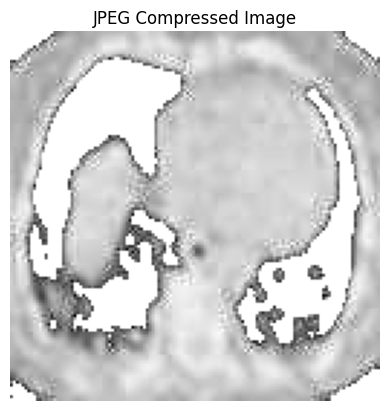

In [23]:
analyze()

Compression of Noisy Image

In [24]:
image_matrix = np.loadtxt('/content/noisy_img_mtrx.csv', delimiter=' ')
image_matrix = (image_matrix * 255).clip(0, 255).astype(np.uint8)

In [36]:
calculate_entropy('/content/noisy_img_mtrx.csv')

np.float64(7.143583390884059)

Original size (bytes): 16384
Compressed size (approx non-zero coeffs): 6302
Compression ratio: 2.60


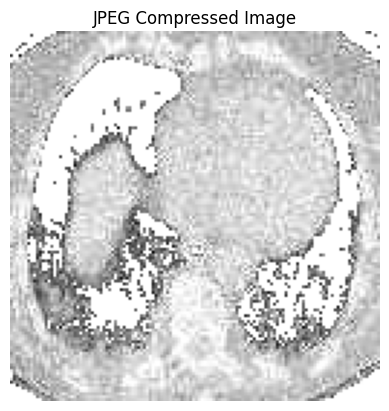

In [25]:
analyze()

CONCLUSION:
  Our autoencoded image achieved a higher compression rate compared to directly compressing the noisy image. This improvement stems from the fact that noisy images have higher entropy, making them less compressible. In contrast, our autoencoder reduces this entropy by removing noise and redundancy before compression. As a result, for the same level of psychovisual redundancy exploitation, fewer bits per source symbol are required for the autoencoded image than for the noisy one. This allows us to achieve better compression while preserving essential features and discarding irrelevant or noisy data.

USES:
  This technique can be applied to efficiently compress and store medical images with minimal distortion, ensuring that critical tasks such as tumor segmentation and diagnosis remain accurate. By preserving essential details while reducing redundant information, it helps lower storage costs without compromising clinical utility.